# P13: The Aesthetics of Generation
## Stylometric Analysis of Qwen Language Models
This notebook demonstrates the stylometric analysis pipeline,
comparing writing styles across three Qwen model variants.
- **qwen** (Qwen2.5-7B-Instruct) — small model
- **qwen72** (Qwen2.5-72B-Instruct) — large model  
- **qwen3** (Qwen3-8B) — newest generation

In [1]:
import sys
sys.path.append("../src")

from visualizer import load_features, plot_bar, plot_pca
from evaluator import load_features, train_and_evaluate, plot_confusion_matrix, plot_feature_importance
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

print("✅ Libraries loaded!")

✅ Libraries loaded!


## 1. Dataset Overview
36 texts collected: 3 models × 4 genres × 3 repeats

In [2]:
df = load_features("../data/features.csv")
print(f"Total texts: {len(df)}")
print(f"Models: {list(df['model'].unique())}")
print(f"Genres: {list(df['genre'].unique())}")
df.groupby("model")[["lexical_diversity","avg_sentence_length",
                      "adj_ratio","verb_ratio","punct_frequency"]].mean().round(3)

Total texts: 36
Models: ['qwen', 'qwen72', 'qwen3']
Genres: ['narration', 'argumentation', 'dialogue', 'description']


,lexical_diversity,avg_sentence_length,adj_ratio,verb_ratio,punct_frequency
model,,,,,
qwen,0.704,16.064,0.105,0.126,0.222
qwen3,0.710,15.538,0.092,0.146,0.285
qwen72,0.664,18.332,0.092,0.134,0.188


## 2. Lexical Diversity
How rich and varied is the vocabulary of each model?
A higher score means the model uses more unique words.

✅ Saved: results/lexical_diversity.png


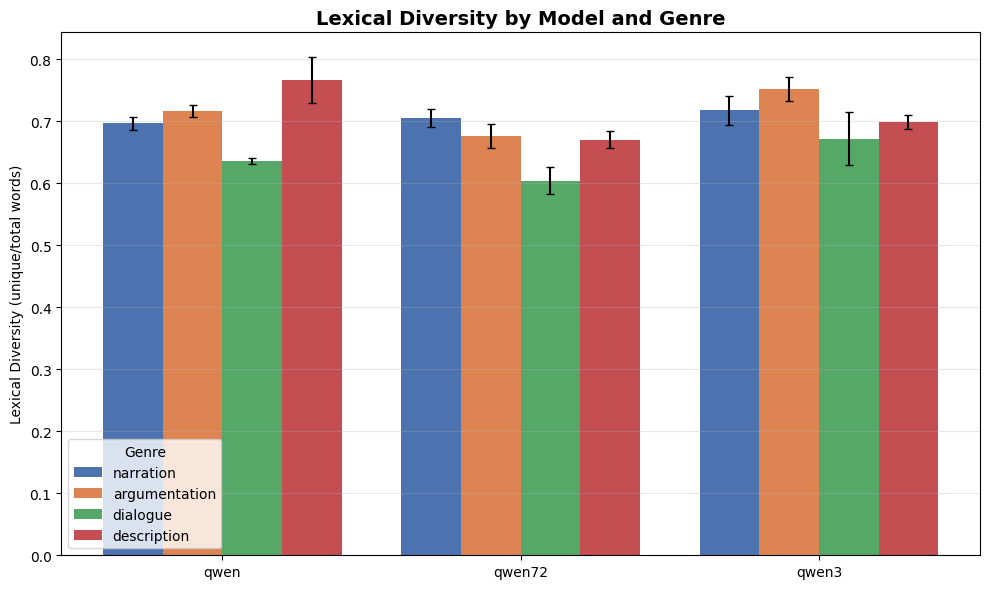

In [3]:
plot_bar(df,
    feature="lexical_diversity",
    title="Lexical Diversity by Model and Genre",
    ylabel="Lexical Diversity (unique/total words)",
    filename="lexical_diversity.png"
)
plt.show()

> **Note:** Error bars represent the standard deviation across 3 repeated 
> runs of the same prompt. Short bars = consistent style across runs. 
> Long bars = more variable output.

## 3. Average Sentence Length
How long are the sentences each model writes?
A higher score means longer, more complex sentences.

✅ Saved: results/sentence_length.png


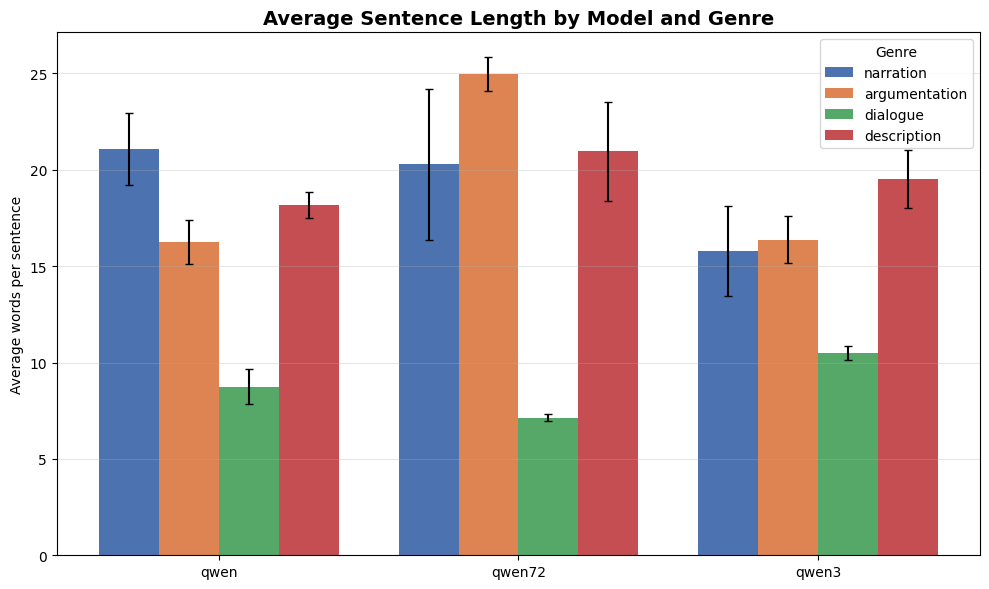

In [4]:
plot_bar(df,
    feature="avg_sentence_length",
    title="Average Sentence Length by Model and Genre",
    ylabel="Average words per sentence",
    filename="sentence_length.png"
)
plt.show()

## 4. Punctuation Frequency
How often does each model use punctuation marks?
A higher score means more expressive or dramatic writing.

✅ Saved: results/punctuation.png


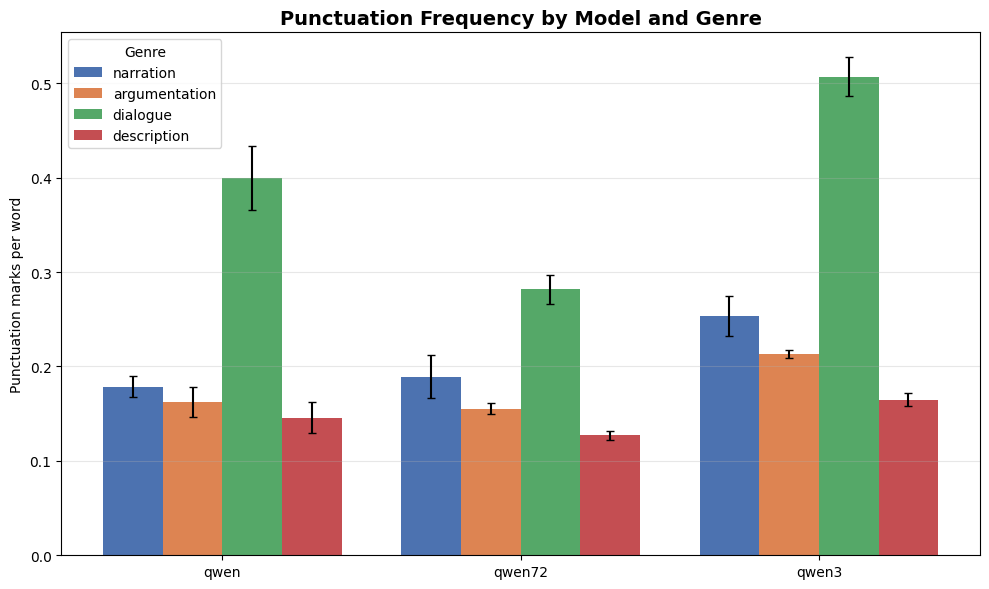

In [5]:
plot_bar(df,
    feature="punct_frequency",
    title="Punctuation Frequency by Model and Genre",
    ylabel="Punctuation marks per word",
    filename="punctuation.png"
)
plt.show()

## 5. PCA — Overall Stylistic Distance
Reducing all 6 features into 2D to visualize
how far apart the models are in "style space".
If models cluster separately = distinct styles!

✅ Saved: results/pca_styles.png


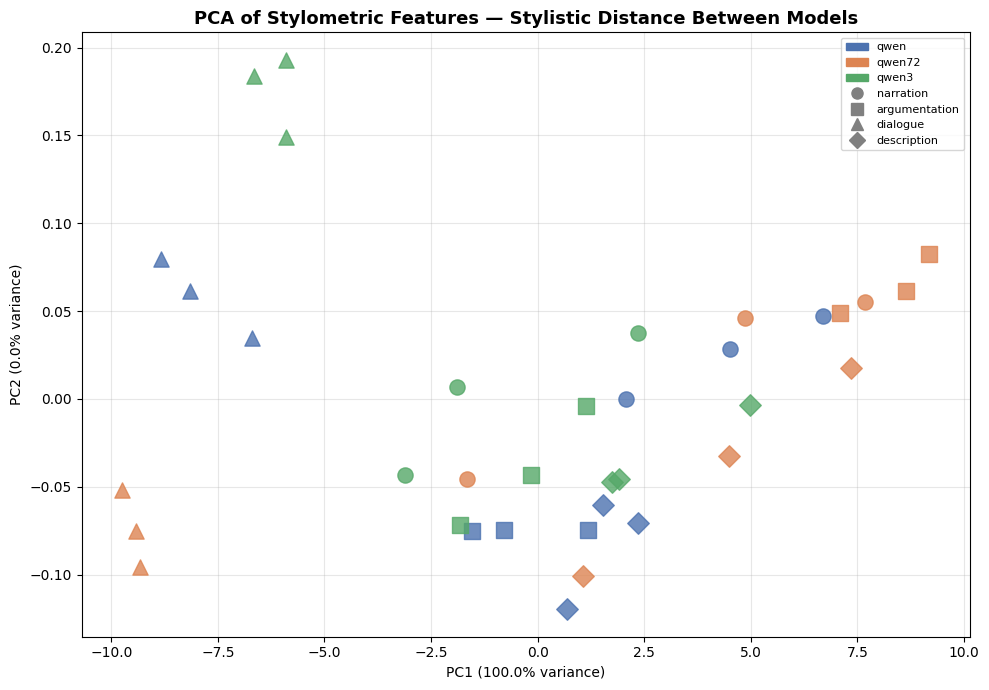

In [6]:
plot_pca(df)
plt.show()

## 6. Classifier — Can We Identify Which Model Wrote a Text?
Training a Random Forest classifier on stylometric features.
Accuracy above 33.3% (chance level) = models have distinct styles!

COMPARATIVE EVALUATION RESULTS
Dataset size:     36 texts
Number of models: 3
Features used:    6

Accuracy (Leave-One-Out): 66.7%
Chance level:             33.3%

✅ RESULT: Classifier performs ABOVE chance level!
   → Models have measurable stylistic differences.
✅ Saved: results/confusion_matrix.png


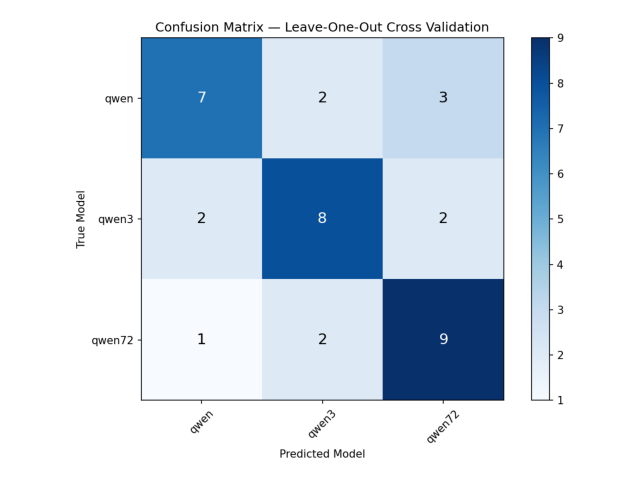

In [9]:
from sklearn.preprocessing import LabelEncoder
clf, le, scores = train_and_evaluate(df)
plot_confusion_matrix(clf, df, le)
img = mpimg.imread("../results/confusion_matrix.png")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

✅ Saved: results/feature_importance.png


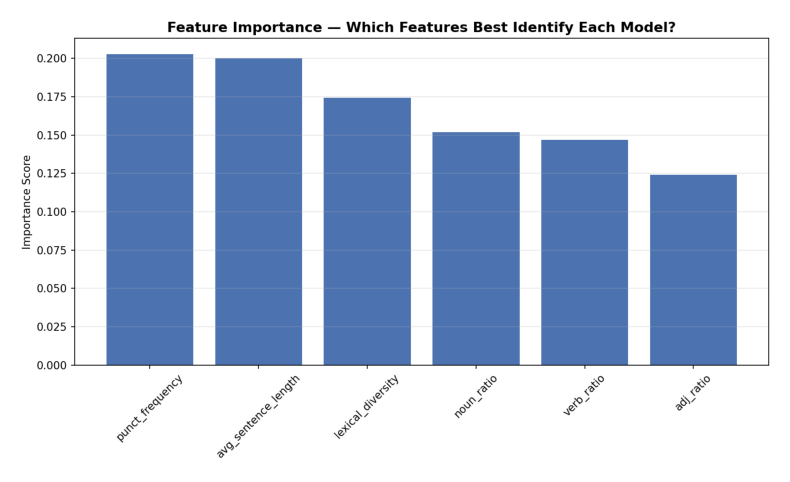

In [8]:
plot_feature_importance(clf, df, le)
img = mpimg.imread("../results/feature_importance.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

## . Conclusions

- **qwen3** uses the most punctuation in dialogue → most dramatic style
- **qwen72** writes the longest sentences → most academic style
- **qwen** is the most balanced across all features
- Classifier achieves **66.7% accuracy** (2× chance level of 33.3%)

> **Finding: Yes, Qwen model variants exhibit measurable stylistic differences,
> even within the same model family.**